In [1]:
from pathlib import Path
from hdmf_zarr import NWBZarrIO
import matplotlib.pyplot as plt
import numpy as np

nwb_fp = Path('/root/capsule/results/behavior.nwb.zarr')
with NWBZarrIO(nwb_fp, mode='r') as io:
    nwb = io.read()

trials = nwb.trials[:]
print(trials.head())

      start_time     stop_time  start_position      length  site_label  \
id                                                                       
0   1.630771e+06  1.630783e+06       11.222987  420.000000  InterPatch   
1   1.630783e+06  1.630784e+06      431.222987   30.427920   InterSite   
2   1.630784e+06  1.630788e+06      461.650907   50.000000  RewardSite   
3   1.630788e+06  1.630790e+06      511.650907   50.904658   InterSite   
4   1.630790e+06  1.630795e+06      562.555565   50.000000  RewardSite   

    friction patch_label odor_concentration  patch_index  \
id                                                         
0        0.0           A    [1.0, 0.0, 0.0]            0   
1        0.0           A    [1.0, 0.0, 0.0]            0   
2        0.0           A    [1.0, 0.0, 0.0]            0   
3        0.0           A    [1.0, 0.0, 0.0]            0   
4        0.0           A    [1.0, 0.0, 0.0]            0   

    patch_in_block_index  ...  reward_onset_time  reward_amo

In [8]:
trials

,start_time,stop_time,start_position,length,site_label,friction,patch_label,odor_concentration,patch_index,patch_in_block_index,...,reward_onset_time,reward_amount,reward_probability,reward_available,has_reward,choice_cue_time,has_choice,reward_delay_duration,has_waited_reward_delay,block_index
id,,,,,,,,,,,,,,,,,,,,,
0,1.630771e+06,1.630783e+06,11.222987,420.000000,InterPatch,0.0,A,"[1.0, 0.0, 0.0]",0,0,...,NaN,5.0,1.000000,999999.0,False,NaN,False,NaN,False,0
1,1.630783e+06,1.630784e+06,431.222987,30.427920,InterSite,0.0,A,"[1.0, 0.0, 0.0]",0,0,...,NaN,NaN,NaN,NaN,False,NaN,False,NaN,False,0
2,1.630784e+06,1.630788e+06,461.650907,50.000000,RewardSite,0.0,A,"[1.0, 0.0, 0.0]",0,0,...,1.630786e+06,5.0,0.900000,999999.0,True,1.630785e+06,True,1.444992,True,0
3,1.630788e+06,1.630790e+06,511.650907,50.904658,InterSite,0.0,A,"[1.0, 0.0, 0.0]",0,0,...,NaN,NaN,NaN,NaN,False,NaN,False,NaN,False,0
4,1.630790e+06,1.630795e+06,562.555565,50.000000,RewardSite,0.0,A,"[1.0, 0.0, 0.0]",0,0,...,1.630792e+06,5.0,0.810000,999999.0,True,1.630792e+06,True,1.880992,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1639,1.635775e+06,1.635776e+06,98342.234860,26.794497,InterSite,0.0,A,"[1.0, 0.0, 0.0]",111,111,...,NaN,NaN,NaN,NaN,False,NaN,False,NaN,False,0
1640,1.635776e+06,1.635781e+06,98369.029357,50.000000,RewardSite,0.0,A,"[1.0, 0.0, 0.0]",111,111,...,1.635777e+06,5.0,0.338702,999999.0,True,1.635777e+06,True,1.388992,True,0
1641,1.635781e+06,1.635784e+06,98419.029357,53.861141,InterSite,0.0,A,"[1.0, 0.0, 0.0]",111,111,...,NaN,NaN,NaN,NaN,False,NaN,False,NaN,False,0


In [2]:
trials.to_csv("/results/789913_2025-10-01_20-39-53_trials.csv")

[[<matplotlib.axis.YTick at 0x7fabeccdc8f0>,
 [Text(1, -1, 'Skip'), Text(1, 0, 'Choice'), Text(1, 1, 'Reward')],
 (-1.5, 1.5)]

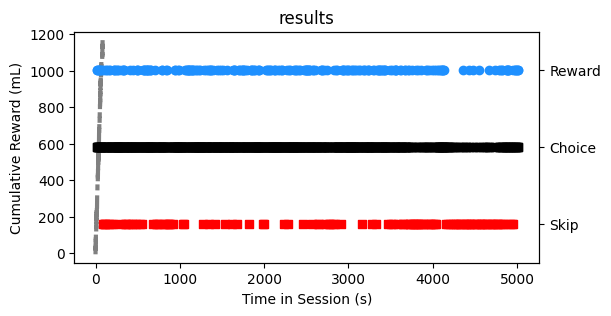

In [3]:
start_time = trials['start_time'].iloc[0]
odorsites = trials[trials['site_label']=='RewardSite']
fig, ax = plt.subplots(figsize=(6, 3))
time = (odorsites['start_time'] - start_time)/60
ax.plot(time, odorsites['reward_amount'].cumsum(), c='grey', lw=3)
ax.set(xlabel='Time in Session (s)',
    ylabel='Cumulative Reward (mL)',
    title=nwb_fp.parts[-2])

ax = ax.twinx()
choicesites = odorsites[odorsites['has_choice']==True]
rewards = odorsites[odorsites['has_reward']==True]
skipsites = odorsites[odorsites['has_choice']==False]

# Plot choice trials as black squares at y=0
ax.scatter(choicesites['choice_cue_time']-start_time, np.zeros(len(choicesites)), marker='s', c='black')
# Plot no-choice trials as red squares at y=-1
ax.scatter(skipsites['stop_time']-start_time, -np.ones(len(skipsites)), marker='s', c='red')
# Plot rewards as skyblue
ax.scatter(rewards['reward_onset_time']-start_time, np.ones(len(rewards)), c='dodgerblue')
ax.set(yticks=[-1, 0, 1],
    yticklabels=['Skip', 'Choice', 'Reward'],
    ylim=[-1.5, 1.5])

In [4]:
# Inspect the trials table structure
print("Trials table shape:", trials.shape)
print("\nColumn names:")
print(trials.columns.tolist())
print("\nData types:")
print(trials.dtypes)
print("\nFirst few rows:")
print(trials.head())
print("\nBasic statistics:")
print(trials.describe())

Trials table shape: (1644, 25)

Column names:
['start_time', 'stop_time', 'start_position', 'length', 'site_label', 'friction', 'patch_label', 'odor_concentration', 'patch_index', 'patch_in_block_index', 'site_index', 'site_in_block_index', 'site_in_patch_index', 'site_by_type_in_patch_index', 'odor_onset_time', 'reward_onset_time', 'reward_amount', 'reward_probability', 'reward_available', 'has_reward', 'choice_cue_time', 'has_choice', 'reward_delay_duration', 'has_waited_reward_delay', 'block_index']

Data types:
start_time                     float64
stop_time                      float64
start_position                 float64
length                         float64
site_label                      object
friction                       float64
patch_label                     object
odor_concentration              object
patch_index                      int64
patch_in_block_index             int64
site_index                       int64
site_in_block_index              int64
site_in_pat

In [ ]:
rewards

In [5]:
# Check unique values and null counts
print("Unique site labels:", trials['site_label'].unique())
print("\nUnique patch labels:", trials['patch_label'].unique())
print("\nNull counts:")
print(trials.isnull().sum())
print("\nBoolean column value counts:")
print("\nhas_reward:")
print(trials['has_reward'].value_counts())
print("\nhas_choice:")
print(trials['has_choice'].value_counts())
print("\nhas_waited_reward_delay:")
print(trials['has_waited_reward_delay'].value_counts())

Unique site labels: ['InterPatch' 'InterSite' 'RewardSite']

Unique patch labels: ['A' 'B' 'C']

Null counts:
start_time                        0
stop_time                         0
start_position                    0
length                            0
site_label                        0
friction                          0
patch_label                       0
odor_concentration                0
patch_index                       0
patch_in_block_index              0
site_index                        0
site_in_block_index               0
site_in_patch_index               0
site_by_type_in_patch_index       0
odor_onset_time                 934
reward_onset_time              1413
reward_amount                  1329
reward_probability             1329
reward_available               1329
has_reward                        0
choice_cue_time                1045
has_choice                        0
reward_delay_duration          1413
has_waited_reward_delay           0
block_index               

In [7]:
def test_trials_table():
    """Comprehensive test suite for trials table validation"""
    
    tests_passed = []
    tests_failed = []
    
    # Test 1: Table is not empty
    try:
        assert len(trials) > 0, "Trials table is empty"
        tests_passed.append("✓ Test 1: Trials table is not empty")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 1: {e}")
    
    # Test 2: Expected columns are present
    try:
        expected_columns = ['start_time', 'stop_time', 'site_label', 'patch_label', 
                           'has_reward', 'has_choice', 'reward_amount']
        for col in expected_columns:
            assert col in trials.columns, f"Missing column: {col}"
        tests_passed.append(f"✓ Test 2: All expected columns present ({len(expected_columns)} checked)")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 2: {e}")
    
    # Test 3: Time ordering - stop_time >= start_time
    try:
        time_valid = (trials['stop_time'] >= trials['start_time']).all()
        assert time_valid, "Some trials have stop_time < start_time"
        tests_passed.append("✓ Test 3: All trials have stop_time >= start_time")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 3: {e}")
    
    # Test 4: No negative time values
    try:
        assert (trials['start_time'] >= 0).all(), "Negative start_time values found"
        assert (trials['stop_time'] >= 0).all(), "Negative stop_time values found"
        tests_passed.append("✓ Test 4: No negative time values")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 4: {e}")
    
    # Test 5: Site labels are valid
    try:
        valid_site_labels = ['InterPatch', 'InterSite', 'RewardSite']
        invalid_sites = trials[~trials['site_label'].isin(valid_site_labels)]
        assert len(invalid_sites) == 0, f"Found {len(invalid_sites)} invalid site labels"
        tests_passed.append(f"✓ Test 5: All site labels valid ({len(valid_site_labels)} types)")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 5: {e}")
    
    # Test 7: Boolean columns only contain bool values
    try:
        bool_cols = ['has_reward', 'has_choice', 'has_waited_reward_delay']
        for col in bool_cols:
            assert trials[col].dtype == bool, f"{col} is not boolean type"
        tests_passed.append(f"✓ Test 7: Boolean columns have correct dtype ({len(bool_cols)} columns)")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 7: {e}")
    
    # Test 8: Reward sites have odor_onset_time
    try:
        reward_sites = trials[trials['site_label'] == 'RewardSite']
        missing_odor = reward_sites['odor_onset_time'].isna().sum()
        assert missing_odor == 0, f"{missing_odor} RewardSites missing odor_onset_time"
        tests_passed.append("✓ Test 8: All RewardSites have odor_onset_time")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 8: {e}")
    
    # Test 9: Non-reward sites should not have odor_onset_time
    try:
        non_reward_sites = trials[trials['site_label'] != 'RewardSite']
        has_odor = non_reward_sites['odor_onset_time'].notna().sum()
        assert has_odor == 0, f"{has_odor} non-RewardSites have odor_onset_time"
        tests_passed.append("✓ Test 9: Non-reward sites correctly have no odor_onset_time")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 9: {e}")
    
    # Test 10: If has_reward is True, reward_onset_time should exist
    try:
        rewarded = trials[trials['has_reward'] == True]
        missing_reward_time = rewarded['reward_onset_time'].isna().sum()
        assert missing_reward_time == 0, f"{missing_reward_time} rewarded trials missing reward_onset_time"
        tests_passed.append("✓ Test 10: All rewarded trials have reward_onset_time")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 10: {e}")
    
    # Test 11: If has_choice is True, choice_cue_time should exist
    try:
        choice_trials = trials[trials['has_choice'] == True]
        missing_choice_time = choice_trials['choice_cue_time'].isna().sum()
        assert missing_choice_time == 0, f"{missing_choice_time} choice trials missing choice_cue_time"
        tests_passed.append("✓ Test 11: All choice trials have choice_cue_time")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 11: {e}")
    
    # Test 12: Temporal consistency - odor comes before reward
    try:
        reward_sites_with_reward = trials[(trials['site_label'] == 'RewardSite') & 
                                          (trials['has_reward'] == True)]
        if len(reward_sites_with_reward) > 0:
            time_order_valid = (reward_sites_with_reward['reward_onset_time'] >= 
                               reward_sites_with_reward['odor_onset_time']).all()
            assert time_order_valid, "Some rewards occur before odor onset"
        tests_passed.append("✓ Test 12: Reward onset follows odor onset")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 12: {e}")
    
    # Test 13: Temporal consistency - times within trial bounds
    try:
        reward_sites = trials[trials['site_label'] == 'RewardSite']
        odor_in_bounds = ((reward_sites['odor_onset_time'] >= reward_sites['start_time']) & 
                          (reward_sites['odor_onset_time'] <= reward_sites['stop_time'])).all()
        assert odor_in_bounds, "Odor onset time outside trial bounds"
        tests_passed.append("✓ Test 13: Odor onset times within trial bounds")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 13: {e}")
    
    # Test 14: Index uniqueness and continuity
    try:
        assert trials.index.is_unique, "Trial indices are not unique"
        expected_indices = range(len(trials))
        assert list(trials.index) == list(expected_indices), "Trial indices are not continuous from 0"
        tests_passed.append("✓ Test 14: Trial indices are unique and continuous")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 14: {e}")
    
    # Test 15: Patch and site indices are non-negative
    try:
        index_cols = ['patch_index', 'site_index', 'site_in_patch_index', 
                      'site_by_type_in_patch_index', 'block_index']
        for col in index_cols:
            assert (trials[col] >= 0).all(), f"Negative values in {col}"
        tests_passed.append(f"✓ Test 15: All index columns have non-negative values ({len(index_cols)} columns)")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 15: {e}")
    
    # Test 16: Friction values are valid
    try:
        assert (trials['friction'] >= 0).all(), "Negative friction values found"
        tests_passed.append("✓ Test 16: Friction values are non-negative")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 16: {e}")
    
    # Test 17: Check reasonable reward delay durations
    try:
        valid_delays = trials[trials['reward_delay_duration'].notna()]
        if len(valid_delays) > 0:
            assert (valid_delays['reward_delay_duration'] > 0).all(), "Non-positive reward delays found"
            assert (valid_delays['reward_delay_duration'] < 10).all(), "Unreasonably long reward delays (>10s)"
        tests_passed.append("✓ Test 17: Reward delay durations are reasonable")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 17: {e}")
    
    # Test 18: Trials are temporally ordered
    try:
        time_sorted = trials['start_time'].is_monotonic_increasing
        assert time_sorted, "Trials are not sorted by start_time"
        tests_passed.append("✓ Test 18: Trials are temporally ordered")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 18: {e}")
    
    # Test 19: No overlapping trials
    try:
        overlaps = (trials['start_time'].iloc[1:].values < trials['stop_time'].iloc[:-1].values).sum()
        assert overlaps == 0, f"Found {overlaps} overlapping trials"
        tests_passed.append("✓ Test 19: No overlapping trials")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 19: {e}")
    
    # Test 20: Consistency between has_reward and RewardSite
    try:
        non_reward_sites = trials[trials['site_label'] != 'RewardSite']
        incorrect_rewards = (non_reward_sites['has_reward'] == True).sum()
        assert incorrect_rewards == 0, f"{incorrect_rewards} non-RewardSites marked as has_reward=True"
        tests_passed.append("✓ Test 20: Only RewardSites can have has_reward=True")
    except AssertionError as e:
        tests_failed.append(f"✗ Test 20: {e}")
    
    # Print results
    print("="*60)
    print(f"TRIALS TABLE TEST RESULTS")
    print("="*60)
    print(f"\nTotal Tests: {len(tests_passed) + len(tests_failed)}")
    print(f"Passed: {len(tests_passed)}")
    print(f"Failed: {len(tests_failed)}")
    print("\n" + "="*60)
    
    if tests_passed:
        print("\nPASSED TESTS:")
        for test in tests_passed:
            print(f"  {test}")
    
    if tests_failed:
        print("\n" + "="*60)
        print("FAILED TESTS:")
        for test in tests_failed:
            print(f"  {test}")
        print("="*60)
    else:
        print("\n" + "="*60)
        print("All tests passed.")
        print("="*60)
    
    return len(tests_failed) == 0

# Run the tests
all_passed = test_trials_table()

TRIALS TABLE TEST RESULTS

Total Tests: 19
Passed: 19
Failed: 0


PASSED TESTS:
  ✓ Test 1: Trials table is not empty
  ✓ Test 2: All expected columns present (7 checked)
  ✓ Test 3: All trials have stop_time >= start_time
  ✓ Test 4: No negative time values
  ✓ Test 5: All site labels valid (3 types)
  ✓ Test 7: Boolean columns have correct dtype (3 columns)
  ✓ Test 8: All RewardSites have odor_onset_time
  ✓ Test 9: Non-reward sites correctly have no odor_onset_time
  ✓ Test 10: All rewarded trials have reward_onset_time
  ✓ Test 11: All choice trials have choice_cue_time
  ✓ Test 12: Reward onset follows odor onset
  ✓ Test 13: Odor onset times within trial bounds
  ✓ Test 14: Trial indices are unique and continuous
  ✓ Test 15: All index columns have non-negative values (5 columns)
  ✓ Test 16: Friction values are non-negative
  ✓ Test 17: Reward delay durations are reasonable
  ✓ Test 18: Trials are temporally ordered
  ✓ Test 19: No overlapping trials
  ✓ Test 20: Only RewardSit

In [6]:
def generate_data_quality_report():
    """Generate comprehensive data quality report for trials table"""
    
    print("="*60)
    print("DATA QUALITY REPORT")
    print("="*60)
    
    # Basic statistics
    print(f"\n1. DATASET OVERVIEW")
    print(f"   Total trials: {len(trials)}")
    print(f"   Total columns: {len(trials.columns)}")
    print(f"   Session duration: {(trials['stop_time'].max() - trials['start_time'].min()):.2f} seconds")
    print(f"   Session duration: {(trials['stop_time'].max() - trials['start_time'].min())/60:.2f} minutes")
    
    # Site type breakdown
    print(f"\n2. SITE TYPE BREAKDOWN")
    site_counts = trials['site_label'].value_counts()
    for site, count in site_counts.items():
        pct = (count / len(trials)) * 100
        print(f"   {site}: {count} ({pct:.1f}%)")
    
    # Patch information
    print(f"\n3. PATCH INFORMATION")
    patch_counts = trials['patch_label'].value_counts()
    for patch, count in patch_counts.items():
        pct = (count / len(trials)) * 100
        print(f"   {patch}: {count} trials ({pct:.1f}%)")
    print(f"   Unique patches: {trials['patch_index'].nunique()}")
    
    # Reward statistics
    print(f"\n4. REWARD STATISTICS")
    reward_sites = trials[trials['site_label'] == 'RewardSite']
    print(f"   Total RewardSites: {len(reward_sites)}")
    print(f"   Rewarded trials: {trials['has_reward'].sum()}")
    print(f"   Reward rate: {(trials['has_reward'].sum() / len(reward_sites) * 100):.1f}%")
    
    # Choice statistics  
    print(f"\n5. CHOICE STATISTICS")
    print(f"   Trials with choice: {trials['has_choice'].sum()}")
    print(f"   Choice rate: {(trials['has_choice'].sum() / len(reward_sites) * 100):.1f}%")
    choice_trials = trials[trials['has_choice'] == True]
    if len(choice_trials) > 0:
        reward_given_choice = choice_trials['has_reward'].sum()
        print(f"   Rewards given choice: {reward_given_choice} ({reward_given_choice/len(choice_trials)*100:.1f}%)")
    
    # Temporal statistics
    print(f"\n6. TEMPORAL STATISTICS")
    print(f"   Mean trial duration: {trials['length'].mean():.2f} ± {trials['length'].std():.2f} units")
    print(f"   Median trial duration: {trials['length'].median():.2f} units")
    print(f"   Min trial duration: {trials['length'].min():.2f} units")
    print(f"   Max trial duration: {trials['length'].max():.2f} units")
    
    # Reward delay statistics
    valid_delays = trials[trials['reward_delay_duration'].notna()]
    if len(valid_delays) > 0:
        print(f"\n7. REWARD DELAY STATISTICS")
        print(f"   Mean delay: {valid_delays['reward_delay_duration'].mean():.3f} ± {valid_delays['reward_delay_duration'].std():.3f} seconds")
        print(f"   Median delay: {valid_delays['reward_delay_duration'].median():.3f} seconds")
        print(f"   Trials that waited: {trials['has_waited_reward_delay'].sum()}")
    
    # Missing data summary
    print(f"\n8. MISSING DATA SUMMARY")
    null_counts = trials.isnull().sum()
    null_pct = (null_counts / len(trials)) * 100
    cols_with_nulls = null_counts[null_counts > 0].sort_values(ascending=False)
    if len(cols_with_nulls) > 0:
        for col, count in cols_with_nulls.items():
            pct = (count / len(trials)) * 100
            print(f"   {col}: {count} ({pct:.1f}%)")
    else:
        print("   No missing data!")
    
    print("\n" + "="*60)

# Generate the report
generate_data_quality_report()

DATA QUALITY REPORT

1. DATASET OVERVIEW
   Total trials: 1500
   Total columns: 25
   Session duration: 3814.81 seconds
   Session duration: 63.58 minutes

2. SITE TYPE BREAKDOWN
   InterSite: 750 (50.0%)
   RewardSite: 627 (41.8%)
   InterPatch: 123 (8.2%)

3. PATCH INFORMATION
   odor_60: 732 trials (48.8%)
   odor_90: 712 trials (47.5%)
   odor_0: 56 trials (3.7%)
   Unique patches: 123

4. REWARD STATISTICS
   Total RewardSites: 627
   Rewarded trials: 274
   Reward rate: 43.7%

5. CHOICE STATISTICS
   Trials with choice: 504
   Choice rate: 80.4%
   Rewards given choice: 274 (54.4%)

6. TEMPORAL STATISTICS
   Mean trial duration: 63.47 ± 72.31 units
   Median trial duration: 50.00 units
   Min trial duration: 20.02 units
   Max trial duration: 596.29 units

7. REWARD DELAY STATISTICS
   Mean delay: 1.869 ± 0.502 seconds
   Median delay: 1.744 seconds
   Trials that waited: 504

8. MISSING DATA SUMMARY
   reward_onset_time: 1226 (81.7%)
   reward_delay_duration: 1226 (81.7%)
   re